In [11]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns


# Load dataset
df_customers = pd.read_csv("q2_customers.csv")

# Display first 5 rows
display(df_customers.head())

# Display shape
print("Shape of dataset:", df_customers.shape)

# Scale all features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_customers)

print("Scaled data shape:", X_scaled.shape)


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


Shape of dataset: (500, 6)
Scaled data shape: (500, 6)


## Why Scaling is Important Before K-Means

Scaling is essential before applying **K-Means clustering** because K-Means works by calculating distances between data points and cluster centroids.

If the features are on different scales, then variables with larger values will dominate the distance calculation. For example, `annual_spend` may have much larger values than `visits_per_month`, so without scaling, the clustering result may depend too much on spending and ignore other useful features.

By using **StandardScaler**, all features are converted to a similar scale with mean 0 and standard deviation 1. This ensures that each feature contributes equally to the clustering process and improves the quality of the customer segments.


WCSS values from K=1 to K=10:
K=1: 3000.0000
K=2: 968.9939
K=3: 561.2530
K=4: 444.9303
K=5: 402.3713
K=6: 370.3854
K=7: 346.9541
K=8: 319.8975
K=9: 303.2823
K=10: 289.1140


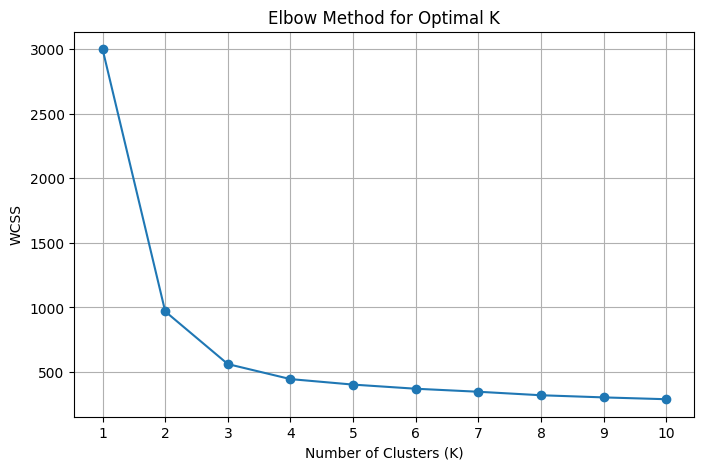

In [12]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

print("WCSS values from K=1 to K=10:")
for k, value in enumerate(wcss, start=1):
    print(f"K={k}: {value:.4f}")

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

## Elbow Method Interpretation

The **Elbow Method** is used to find the optimal number of clusters by plotting **WCSS (Within-Cluster Sum of Squares)** against different values of **K**.

From the plot, the WCSS drops very sharply from **K = 1 to K = 3**, and then the decrease becomes slower after that. This indicates that adding more clusters after **K = 3** does not significantly improve clustering.

Therefore, the **optimal number of clusters is K = 3**, because this is the point where the curve starts to bend and form an "elbow".

Thus,
- We can see large reduction in WCSS from **1 to 2** and **2 to 3**
- and also smaller reduction can be seen after **K = 3**
- So, **3 clusters** provide a good balance between cluster compactness and model simplicity.

In [13]:
## Fitting K-Means and adding cluster labels
# Fit K-Means with chosen K = 3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
df_customers["cluster"] = clusters

# Show first few rows
display(df_customers.head())

## Print cluster size
print("Number of customers in each cluster:\n")
print(df_customers["cluster"].value_counts().sort_index())

# Convert centroids back to original scale
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)

centroids_df = pd.DataFrame(
    centroids_original,
    columns=df_customers.drop(columns=["cluster"]).columns
)

centroids_df.index = [f"Cluster {i}" for i in range(3)]
centroids_df = centroids_df.round(2)

print("Cluster Centroids:\n")
display(centroids_df)

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


Number of customers in each cluster:

cluster
0    170
1    165
2    165
Name: count, dtype: int64
Cluster Centroids:



,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
Cluster 0,24.68,14847.37,14.34,558.97,9.08,2.11
Cluster 1,56.77,89413.33,2.53,5530.55,105.36,7.52
Cluster 2,40.39,43340.73,8.19,2021.68,35.19,4.42


## Cluster Interpretation in Business Terms

Based on the centroid values, the three customer segments can be interpreted as follows:

### Cluster 0: Young, low-value occasional shoppers
- Average age is around **25 years**
- Lowest **annual spend**
- Fewer **visits per month**
- Smallest **basket size**
- Longest time since last visit
- Purchase from fewer product categories

**Business Interpretation:**  
This cluster represents **young, infrequent, low-spending customers**. They are less engaged and may respond well to discounts, loyalty offers, or campaigns designed to increase visit frequency.

### Cluster 1: Older, high-value loyal customers
- Average age is around **57 years**
- Highest **annual spend**
- Highest **visits per month**
- Largest **basket size**
- Very recent visits
- Purchase from the highest number of categories

**Business Interpretation:**  
This cluster represents **older, highly loyal, high-spending customers**. They are the most valuable segment and should be retained through premium services, personalized rewards, and relationship-focused marketing.

### Cluster 2: Middle-aged, moderate-value regular customers
- Average age is around **40 years**
- Medium **annual spend**
- Moderate **visit frequency**
- Medium **basket size**
- Moderately recent visits
- Purchase across a moderate number of categories

**Business Interpretation:**  
This cluster represents **middle-aged, regular medium-spending customers**. They are active and valuable, with potential to be converted into high-value customers through upselling and cross-selling strategies.
Very short version

In [14]:
# Apply PCA to reduce to 2 principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Print explained variance ratio
print("Explained Variance Ratio:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.4f}")

loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=df_customers.drop(columns=["cluster"], errors="ignore").columns
)

##feature loadings (components) as a readable dataframe
print("PCA Feature Loadings:")
display(loadings_df.round(4))

Explained Variance Ratio:
PC1: 0.8356
PC2: 0.0557
PCA Feature Loadings:


,PC1,PC2
age,0.4116,-0.2594
annual_spend,0.4215,-0.0333
visits_per_month,-0.4104,0.2083
basket_size,0.4120,-0.1954
days_since_last_visit,0.3786,0.9112
num_categories_purchased,0.4140,-0.1405


## Interpretation of PCA Components

The first two principal components were created to reduce the six original customer features into two new variables.

### Explained Variance
- **PC1 explains 83.56%** of the total variance
- **PC2 explains 5.57%** of the total variance

This means that **PC1 captures most of the information** in the dataset, while **PC2 captures a smaller but still useful pattern**.

### Interpretation of PC1
PC1 has strong positive loadings for:
- `age`
- `annual_spend`
- `basket_size`
- `num_categories_purchased`
- `days_since_last_visit`

and a strong negative loading for:
- `visits_per_month`

This suggests that **PC1 mainly captures overall customer value and behaviour level**, separating customers based on spending, basket size, category variety, and age, while also contrasting them with visit frequency.

### Interpretation of PC2
PC2 is dominated by a very strong positive loading for:
- `days_since_last_visit`

This means that **PC2 mainly captures recency behaviour**, especially how long it has been since the customer last visited. So, this component helps distinguish recently active customers from inactive ones.

### Overall Interpretation
- **PC1** represents a broad customer profile combining spending and purchasing behaviour.
- **PC2** mainly represents customer recency or inactivity.

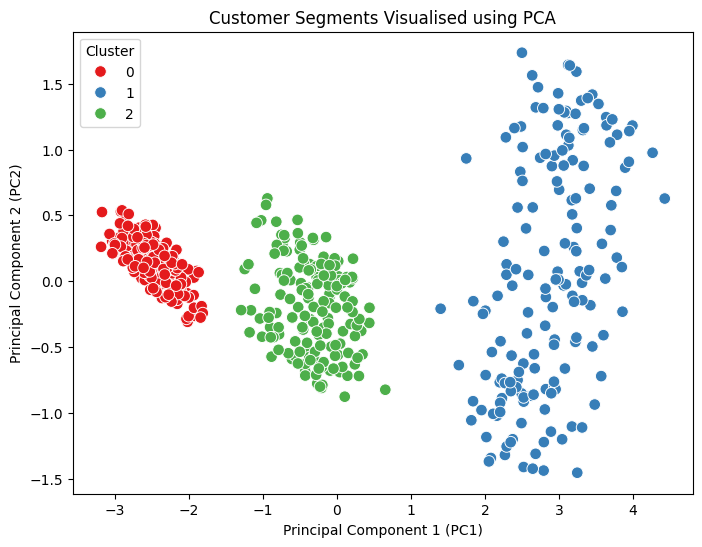

In [15]:
# Create a dataframe for PCA results with cluster labels
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["cluster"] = df_customers["cluster"]

# Scatter plot of PC1 vs PC2
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cluster", palette="Set1", s=70)

plt.title("Customer Segments Visualised using PCA")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend(title="Cluster")
plt.show()